In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# ── Load data ─────────────────────────────────────────────────────────────────
clients = pd.read_csv("/data/cust_branch_dataset CLEANED.csv")
fact    = pd.read_csv("/data/fact_cust_product.csv")

# ── Compute derived fields from fact table ────────────────────────────────────
active_fact = fact[fact["active_flag"] == "Y"].copy()

# Total deposit balance per client
deposit_agg = (
    active_fact
    .query("product_group == 'Deposit'")
    .groupby("cust_id")
    .agg(total_deposit_balance=("balance", "sum"))
    .reset_index()
)

# IBB (interest-bearing) balance per client
ibb_agg = (
    active_fact
    .query("deposit_category == 'IBB'")
    .groupby("cust_id")
    .agg(ibb_balance=("balance", "sum"))
    .reset_index()
)

# NIDDA (non-interest) balance per client
nidda_agg = (
    active_fact
    .query("deposit_category == 'NIDDA'")
    .groupby("cust_id")
    .agg(nidda_balance=("balance", "sum"))
    .reset_index()
)

# Total active products per client
products_agg = (
    active_fact
    .groupby("cust_id")
    .agg(total_products=("product_type", "nunique"))
    .reset_index()
)

# Credit card flag per client (already in fact, deduplicate)
cc_agg = (
    fact
    .drop_duplicates(subset=["cust_id"])
    [["cust_id", "has_credit_card"]]
)

# ── Merge all aggregations into clients ───────────────────────────────────────
active = (
    clients
    .merge(deposit_agg,  on="cust_id", how="left")
    .merge(ibb_agg,      on="cust_id", how="left")
    .merge(nidda_agg,    on="cust_id", how="left")
    .merge(products_agg, on="cust_id", how="left")
    .merge(cc_agg,       on="cust_id", how="left")
)

# Fill nulls for clients with no product in a category
active["total_deposit_balance"] = active["total_deposit_balance"].fillna(0)
active["ibb_balance"]           = active["ibb_balance"].fillna(0)
active["nidda_balance"]         = active["nidda_balance"].fillna(0)
active["total_products"]        = active["total_products"].fillna(0).astype(int)
active["has_credit_card"]       = active["has_credit_card"].fillna(0).astype(int)
active["uses_mobile_banking"]   = active["uses_mobile_banking"].astype(int)

# ── Compute coverage tier from branches_within_1km ───────────────────────────
def coverage_tier(n):
    if n == 0:    return "No Nearby Branch"
    elif n <= 2:  return "Low Coverage (1-2)"
    elif n <= 5:  return "Moderate Coverage (3-5)"
    elif n <= 10: return "High Coverage (6-10)"
    else:         return "Very High Coverage (10+)"

active["branch_coverage_tier"] = active["branches_within_1km"].apply(coverage_tier)

tier_order = [
    "No Nearby Branch", "Low Coverage (1-2)",
    "Moderate Coverage (3-5)", "High Coverage (6-10)",
    "Very High Coverage (10+)"
]
active["branch_coverage_tier"] = pd.Categorical(
    active["branch_coverage_tier"], categories=tier_order, ordered=True
)

print(f"Active clients loaded: {len(active):,}")
print(f"Columns: {active.columns.tolist()}\n")

Active clients loaded: 5,000
Columns: ['cust_id', 'cust_name', 'first_acct_open_dt', 'tenure_days', 'branches_within_1km', 'uses_mobile_banking', 'avg_daily_txn_count', 'cust_city', 'cust_neighbourhood', 'employee_id', 'employee_name', 'employee_title', 'top1_branch_id', 'top1_km', 'top1_minutes', 'top1_bank_name', 'top1_lat', 'top1_lon', 'top1_address', 'top1_city', 'top1_postal_code', 'top1_manager_name', 'top1_manager_title', 'top2_branch_id', 'top2_km', 'top2_minutes', 'top2_bank_name', 'top2_lat', 'top2_lon', 'top2_address', 'top2_city', 'top2_postal_code', 'top2_manager_name', 'top2_manager_title', 'top3_branch_id', 'top3_km', 'top3_minutes', 'top3_bank_name', 'top3_lat', 'top3_lon', 'top3_address', 'top3_city', 'top3_postal_code', 'top3_manager_name', 'top3_manager_title', 'primary_branch_id', 'primary_branch_in_top3', 'primary_bank_name', 'primary_branch_lat', 'primary_branch_lon', 'primary_branch_address', 'primary_branch_city', 'primary_branch_postal_code', 'primary_branch_km

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# DESCRIPTIVE ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

desc = (
    active
    .groupby("branch_coverage_tier", observed=True)
    .agg(
        client_count    = ("cust_id", "nunique"),
        avg_tenure_days = ("tenure_days", "mean"),
        avg_daily_txn   = ("avg_daily_txn_count", "mean"),
        avg_deposit     = ("total_deposit_balance", "mean"),
        total_deposit   = ("total_deposit_balance", "sum"),
    )
    .round(2)
    .reset_index()
)
print("── Descriptive: Avg Deposit by Coverage Tier ──")
print(desc)

── Descriptive: Avg Deposit by Coverage Tier ──
       branch_coverage_tier  client_count  avg_tenure_days  avg_daily_txn  \
0          No Nearby Branch          1857          2759.70           0.74   
1        Low Coverage (1-2)          1608          2694.08           0.87   
2   Moderate Coverage (3-5)          1175          2736.41           1.07   
3      High Coverage (6-10)           269          2741.46           1.32   
4  Very High Coverage (10+)            91          2536.73           1.46   

   avg_deposit  total_deposit  
0     21419.39    39775812.39  
1     29141.37    46859323.69  
2     39742.78    46697770.82  
3     44024.71    11842646.30  
4     69604.73     6334030.65  


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# TOP N CONCENTRATION
# ══════════════════════════════════════════════════════════════════════════════

active["deposit_quintile"] = pd.qcut(
    active["total_deposit_balance"],
    q=5,
    labels=["Q5 (Bottom)", "Q4", "Q3", "Q2", "Q1 (Top)"]
)

top_n = (
    active
    .groupby("deposit_quintile", observed=True)
    .agg(
        client_count  = ("cust_id", "nunique"),
        total_deposit = ("total_deposit_balance", "sum"),
    )
    .assign(pct_of_total=lambda df: (df["total_deposit"] / df["total_deposit"].sum() * 100).round(2))
    .round(2)
    .reset_index()
)
print("\n── Top N Concentration: Deposit Quintile Share ──")
print(top_n)


── Top N Concentration: Deposit Quintile Share ──
  deposit_quintile  client_count  total_deposit  pct_of_total
0      Q5 (Bottom)          1000   2.609133e+06          1.72
1               Q4          1000   5.971264e+06          3.94
2               Q3          1000   1.123848e+07          7.42
3               Q2          1000   2.401784e+07         15.85
4         Q1 (Top)          1000   1.076729e+08         71.07


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# SHARE OF TOTAL
# ══════════════════════════════════════════════════════════════════════════════

ibb_share = (
    active
    .groupby("primary_bank_name")
    .agg(
        ibb_total   = ("ibb_balance", "sum"),
        nidda_total = ("nidda_balance", "sum"),
        dep_total   = ("total_deposit_balance", "sum"),
    )
    .assign(
        ibb_pct   = lambda df: (df["ibb_total"]  / df["dep_total"] * 100).round(2),
        nidda_pct = lambda df: (df["nidda_total"] / df["dep_total"] * 100).round(2),
    )
    .sort_values("ibb_pct", ascending=False)
    .reset_index()
)
print("\n── Share of Total: IBB vs NIDDA by Bank ──")
print(ibb_share)


── Share of Total: IBB vs NIDDA by Bank ──
      primary_bank_name    ibb_total  nidda_total    dep_total  ibb_pct  \
0                   RBC  22995079.43   7487896.36  30482975.79    75.44   
1         National Bank   1899044.06    624566.13   2523610.19    75.25   
2                  CIBC  26764791.19   9264122.97  36028914.16    74.29   
3                    TD  21220705.43   7945604.64  29166310.07    72.76   
4            Scotiabank  19261917.08   7227518.03  26489435.11    72.72   
5       TD Canada Trust   6279855.07   2488234.36   8768089.43    71.62   
6                   BMO  12534096.73   5130589.45  17664686.18    70.96   
7  BMO Bank Of Montreal    267285.39    118277.53    385562.92    69.32   

   nidda_pct  
0      24.56  
1      24.75  
2      25.71  
3      27.24  
4      27.28  
5      28.38  
6      29.04  
7      30.68  


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# GROUP COMPARISONS
# ══════════════════════════════════════════════════════════════════════════════

mobile_compare = (
    active
    .groupby("uses_mobile_banking")
    .agg(
        client_count     = ("cust_id", "nunique"),
        avg_deposit      = ("total_deposit_balance", "mean"),
        avg_products     = ("total_products", "mean"),
        avg_daily_txn    = ("avg_daily_txn_count", "mean"),
        avg_km_to_branch = ("primary_branch_km", "mean"),
    )
    .round(2)
    .sort_values("avg_deposit", ascending=False)
    .reset_index()
)
print("\n── Group Comparison: Mobile vs Non-Mobile ──")
print(mobile_compare)

bypass_compare = (
    active
    .groupby("primary_branch_in_top3")
    .agg(
        client_count     = ("cust_id", "nunique"),
        avg_km_to_branch = ("primary_branch_km", "mean"),
        avg_daily_txn    = ("avg_daily_txn_count", "mean"),
        avg_deposit      = ("total_deposit_balance", "mean"),
        avg_products     = ("total_products", "mean"),
    )
    .round(2)
    .sort_values("avg_deposit", ascending=False)
    .reset_index()
)
print("\n── Group Comparison: Bypass vs Non-Bypass ──")
print(bypass_compare)



── Group Comparison: Mobile vs Non-Mobile ──
   uses_mobile_banking  client_count  avg_deposit  avg_products  \
0                    0           680     32942.67          2.84   
1                    1          4320     29886.24          2.79   

   avg_daily_txn  avg_km_to_branch  
0           0.82              1.45  
1           0.92              2.08  

── Group Comparison: Bypass vs Non-Bypass ──
   primary_branch_in_top3  client_count  avg_km_to_branch  avg_daily_txn  \
0                    True          4166              1.43           0.91   
1                   False           834              4.77           0.85   

   avg_deposit  avg_products  
0     31327.58          2.79  
1     25178.52          2.81  


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# SEGMENTATION ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

segment = (
    active
    .groupby(["branch_coverage_tier", "uses_mobile_banking"], observed=True)
    .agg(
        client_count    = ("cust_id", "nunique"),
        avg_deposit     = ("total_deposit_balance", "mean"),
        avg_products    = ("total_products", "mean"),
        avg_daily_txn   = ("avg_daily_txn_count", "mean"),
        avg_tenure_days = ("tenure_days", "mean"),
    )
    .round(2)
    .reset_index()
    .sort_values(["branch_coverage_tier", "avg_deposit"], ascending=[True, False])
)
print("\n── Segmentation: Coverage Tier x Digital Adoption ──")
print(segment)

cc_segment = (
    active
    .groupby("has_credit_card")
    .agg(
        client_count    = ("cust_id", "nunique"),
        avg_deposit     = ("total_deposit_balance", "mean"),
        avg_products    = ("total_products", "mean"),
        avg_daily_txn   = ("avg_daily_txn_count", "mean"),
        avg_tenure_days = ("tenure_days", "mean"),
    )
    .round(2)
    .sort_values("avg_deposit", ascending=False)
    .reset_index()
)
print("\n── Segmentation: Credit Card Holders vs Non-Holders ──")
print(cc_segment)



── Segmentation: Coverage Tier x Digital Adoption ──
       branch_coverage_tier  uses_mobile_banking  client_count  avg_deposit  \
0          No Nearby Branch                    0           159     23447.74   
1          No Nearby Branch                    1          1698     21229.46   
2        Low Coverage (1-2)                    0           174     31045.73   
3        Low Coverage (1-2)                    1          1434     28910.30   
5   Moderate Coverage (3-5)                    1           949     42002.72   
4   Moderate Coverage (3-5)                    0           226     30253.03   
6      High Coverage (6-10)                    0            78     54764.81   
7      High Coverage (6-10)                    1           191     39638.70   
9  Very High Coverage (10+)                    1            48     86916.73   
8  Very High Coverage (10+)                    0            43     50279.72   

   avg_products  avg_daily_txn  avg_tenure_days  
0          2.76           


── Correlation: Distance Band vs Deposit & Behaviour ──
  distance_band  client_count  avg_deposit  avg_daily_txn  mobile_adoption_pct
0      < 0.5 km          1225     41466.16           1.08                79.67
1    0.5-1.0 km          1629     32400.68           0.94                85.39
2    1.0-2.0 km          1112     24144.79           0.78                90.38
3    2.0-5.0 km           518     21431.86           0.78                92.08
4       5.0+ km           516     19345.20           0.73                91.28

── Correlation: Tenure Band vs Deposit & Products ──
  tenure_band  client_count  avg_deposit  avg_products  avg_daily_txn
0      < 1 yr           335     28282.27          2.86           0.91
1     1-3 yrs           642     31915.26          2.88           0.86
2     3-7 yrs          1384     28769.81          2.77           0.93
3    7-12 yrs          1637     29040.22          2.80           0.89
4     12+ yrs          1000     34153.02          2.75           

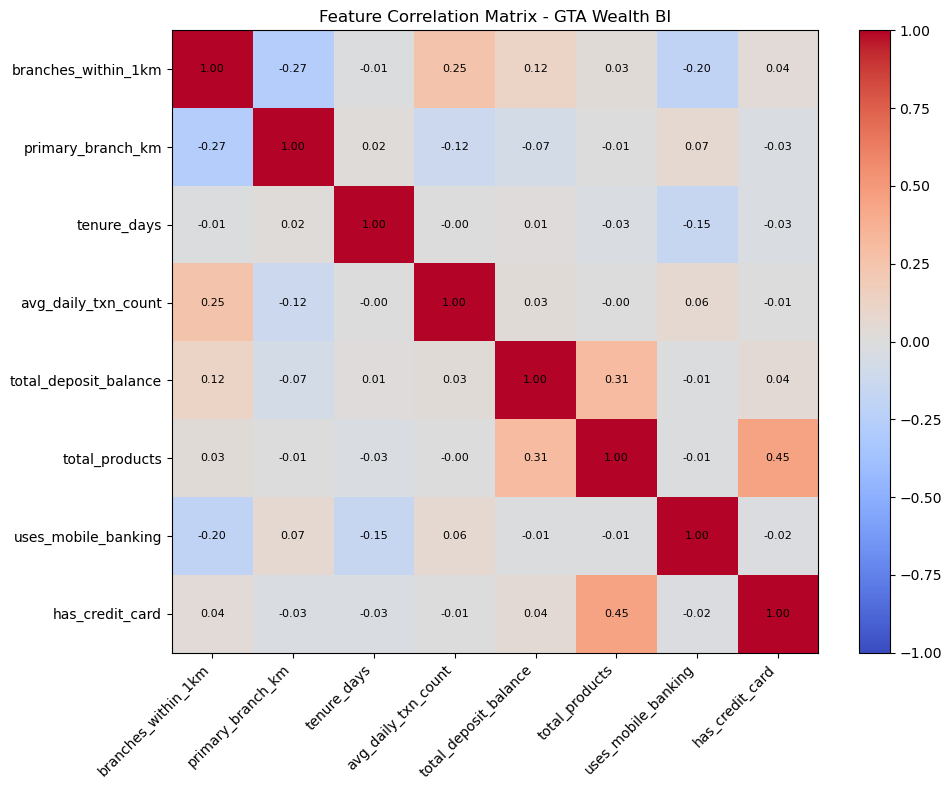

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# CORRELATION EXPLORATION
# ══════════════════════════════════════════════════════════════════════════════

active["distance_band"] = pd.cut(
    active["primary_branch_km"],
    bins=[0, 0.5, 1.0, 2.0, 5.0, np.inf],
    labels=["< 0.5 km", "0.5-1.0 km", "1.0-2.0 km", "2.0-5.0 km", "5.0+ km"]
)

dist_corr = (
    active
    .groupby("distance_band", observed=True)
    .agg(
        client_count        = ("cust_id", "nunique"),
        avg_deposit         = ("total_deposit_balance", "mean"),
        avg_daily_txn       = ("avg_daily_txn_count", "mean"),
        mobile_adoption_pct = ("uses_mobile_banking", lambda x: x.mean() * 100),
    )
    .round(2)
    .reset_index()
)
print("\n── Correlation: Distance Band vs Deposit & Behaviour ──")
print(dist_corr)

active["tenure_band"] = pd.cut(
    active["tenure_days"],
    bins=[0, 365, 365*3, 365*7, 365*12, np.inf],
    labels=["< 1 yr", "1-3 yrs", "3-7 yrs", "7-12 yrs", "12+ yrs"]
)

tenure_corr = (
    active
    .groupby("tenure_band", observed=True)
    .agg(
        client_count  = ("cust_id", "nunique"),
        avg_deposit   = ("total_deposit_balance", "mean"),
        avg_products  = ("total_products", "mean"),
        avg_daily_txn = ("avg_daily_txn_count", "mean"),
    )
    .round(2)
    .reset_index()
)
print("\n── Correlation: Tenure Band vs Deposit & Products ──")
print(tenure_corr)

# Pearson correlation matrix
corr_cols = [
    "branches_within_1km", "primary_branch_km", "tenure_days",
    "avg_daily_txn_count", "total_deposit_balance",
    "total_products", "uses_mobile_banking", "has_credit_card"
]
corr_matrix = active[corr_cols].corr().round(3)
print("\n── Pearson Correlation Matrix ──")
print(corr_matrix)

# Correlation heatmap (matplotlib only, no seaborn)
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Feature Correlation Matrix - GTA Wealth BI")
plt.tight_layout()
plt.show()


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# GEOSPATIAL / SPATIAL ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

neighbourhood = (
    active
    .groupby(["cust_neighbourhood", "cust_city"])
    .agg(
        client_count        = ("cust_id", "nunique"),
        avg_branches_1km    = ("branches_within_1km", "mean"),
        avg_km_to_branch    = ("primary_branch_km", "mean"),
        avg_deposit         = ("total_deposit_balance", "mean"),
        mobile_adoption_pct = ("uses_mobile_banking", lambda x: x.mean() * 100),
    )
    .round(2)
    .reset_index()
    .query("client_count >= 10")
    .sort_values("avg_branches_1km", ascending=False)
)
print("\n── Spatial: Neighbourhood-Level Accessibility & Deposits ──")
print(neighbourhood)

city_compare = (
    active
    .groupby("cust_city")
    .agg(
        client_count        = ("cust_id", "nunique"),
        avg_branches_1km    = ("branches_within_1km", "mean"),
        avg_km_to_branch    = ("primary_branch_km", "mean"),
        mobile_adoption_pct = ("uses_mobile_banking", lambda x: x.mean() * 100),
        avg_daily_txn       = ("avg_daily_txn_count", "mean"),
        avg_deposit         = ("total_deposit_balance", "mean"),
        avg_products        = ("total_products", "mean"),
    )
    .round(2)
    .sort_values("avg_deposit", ascending=False)
    .reset_index()
)
print("\n── Spatial: Toronto vs Outside Toronto ──")
print(city_compare)


── Spatial: Neighbourhood-Level Accessibility & Deposits ──
       cust_neighbourhood        cust_city  client_count  avg_branches_1km  \
73   Kensington-Chinatown          Toronto            13             25.08   
92              Moss Park          Toronto            10             17.30   
135            University          Toronto            13             11.31   
154        Yonge-Eglinton          Toronto            13             10.08   
82        Little Portugal          Toronto            10              8.60   
..                    ...              ...           ...               ...   
121   Scarborough Village          Toronto            12              0.33   
107       Outside Toronto  Outside Toronto          1000              0.32   
91    Morningside Heights          Toronto           172              0.29   
90            Morningside          Toronto            47              0.26   
93           Mount Dennis          Toronto            17              0.24   

  

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# REGRESSION ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

active["deposit_decile"] = pd.qcut(
    active["total_deposit_balance"],
    q=10,
    labels=[f"D{i}" for i in range(1, 11)]
)

decile_profile = (
    active
    .groupby("deposit_decile", observed=True)
    .agg(
        client_count = ("cust_id", "nunique"),
        avg_deposit  = ("total_deposit_balance", "mean"),
        avg_coverage = ("branches_within_1km", "mean"),
        avg_km       = ("primary_branch_km", "mean"),
        avg_tenure   = ("tenure_days", "mean"),
        mobile_pct   = ("uses_mobile_banking", lambda x: x.mean() * 100),
        avg_txn      = ("avg_daily_txn_count", "mean"),
        avg_products = ("total_products", "mean"),
        cc_hold_pct  = ("has_credit_card", lambda x: x.mean() * 100),
    )
    .round(2)
    .reset_index()
)
print("\n── Regression Proxy: Deposit Decile Feature Profile ──")
print(decile_profile)

# OLS regression: predict deposit balance from accessibility and behavioural features
features = [
    "branches_within_1km", "primary_branch_km", "tenure_days",
    "avg_daily_txn_count", "total_products",
    "uses_mobile_banking", "has_credit_card"
]
target = "total_deposit_balance"

X = active[features].fillna(0)
y = active[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

print(f"\n── OLS Regression Results ──")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")
print(f"MAE : ${mean_absolute_error(y_test, y_pred):,.0f}")

coef_df = (
    pd.DataFrame({"feature": features, "coefficient": model.coef_})
    .sort_values("coefficient", ascending=False)
    .reset_index(drop=True)
)
print("\nFeature Coefficients:")
print(coef_df)


── Regression Proxy: Deposit Decile Feature Profile ──
  deposit_decile  client_count  avg_deposit  avg_coverage  avg_km  avg_tenure  \
0             D1           500      1812.90          1.81    2.20     2693.45   
1             D2           500      3405.37          1.83    2.04     2743.98   
2             D3           500      5015.07          1.71    2.22     2701.10   
3             D4           500      6927.46          1.94    2.06     2718.84   
4             D5           500      9454.47          1.78    2.22     2798.08   
5             D6           500     13022.49          1.96    2.08     2731.43   
6             D7           500     19000.16          1.94    2.18     2631.80   
7             D8           500     29035.53          2.16    1.97     2689.33   
8             D9           500     49119.07          2.69    1.54     2814.57   
9            D10           500    166226.65          3.41    1.39     2758.28   

   mobile_pct  avg_txn  avg_products  cc_hold_pct  
